In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import math

# 1. The New Model Architecture
class TemporalBitTransformer(nn.Module):
    def __init__(self, num_classes=4, window_size=50, input_bits=64, d_model=64, nhead=4):
        super().__init__()
        
        # REPLACEMENT: Project the 50-frame history of ONE bit into a vector
        self.history_projection = nn.Linear(window_size, d_model)
        
        # Positional Embedding for the 64 bits (Spatial position)
        self.position_embedding = nn.Parameter(torch.randn(1, input_bits, d_model))
        
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        
        # Classifier projects to class logits
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # Input x from DataLoader: [Batch, Window(50), Bits(64)]
        
        # 1. Permute to [Batch, Bits, Window] so 'Window' becomes the feature dimension
        x = x.permute(0, 2, 1) 
        
        # 2. Project History [Batch, 64, 50] -> [Batch, 64, d_model]
        x = self.history_projection(x)
        
        # 3. Add Position (Bit Identity)
        x = x + self.position_embedding
        
        # 4. Transformer (Inter-bit communication)
        # The transformer now learns relationships between bits based on their temporal history
        x = self.transformer(x) # [Batch, 64, d_model]
        
        # 5. Classify per bit
        x = self.classifier(x) # [Batch, 64, num_classes]
        
        # 6. Aggregate to Global Label
        # We use Max Pooling here. If ANY bit is identified as a Counter, 
        # the max value for the Counter class will be high.
        logits, _ = torch.max(x, dim=1) # [Batch, num_classes]
        
        return logits

# 2. Helper: Dataset Class (Same as before)
class CANDataset(Dataset):
    def __init__(self, df_can, label_map, window_size=50, stride=10, max_samples=3000, mode='diff'):
        self.window_size = window_size
        self.label_map = label_map
        self.windows = []
        self.mode = mode 
        
        grouped = df_can.groupby('id')
        for can_id, group in grouped:
            if can_id not in self.label_map:
                continue
            
            payload_list = group['payload'].tolist()
            
            # Convert Hex to Bits
            raw_tensor = torch.stack([self.payload_to_bits(p) for p in payload_list])
            
            # Mode selection
            if self.mode == 'diff':
                data_tensor = torch.logical_xor(raw_tensor[1:], raw_tensor[:-1]).float()
            else:
                data_tensor = raw_tensor.float()
            
            label = self.label_map[can_id]
            
            # Windowing
            current_id_windows = []
            for i in range(0, len(data_tensor) - window_size + 1, stride):
                window_data = data_tensor[i : i + window_size]
                current_id_windows.append((window_data, label))
            
            if len(current_id_windows) > max_samples:
                import random
                current_id_windows = random.sample(current_id_windows, max_samples)
                
            self.windows.extend(current_id_windows)

    def payload_to_bits(self, hex_str):
        padded_hex = hex_str.ljust(16, '0')
        try:
            raw_bytes = bytes.fromhex(padded_hex)
        except ValueError:
            raw_bytes = bytes(8)
        binary_str = ''.join(f'{byte:08b}' for byte in raw_bytes)
        return torch.tensor([int(bit) for bit in binary_str], dtype=torch.uint8)

    def __len__(self):
        return len(self.windows)
    
    def __getitem__(self, index):
        return self.windows[index]

# 3. Training Function
def train_model(model, optimizer, train_dataloader, val_dataloader, num_epochs=10, device='cuda'):
    loss_fn = nn.BCEWithLogitsLoss()
    
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        
        for sequences, labels in train_dataloader:
            sequences = sequences.to(device)
            labels = labels.to(device)
            
            logits = model(sequences)
            loss = loss_fn(logits, labels.float())
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for sequences, labels in val_dataloader:
                sequences = sequences.to(device)
                labels = labels.to(device)
                logits = model(sequences)
                preds = (torch.sigmoid(logits) > 0.5).float()
                all_correct = (preds == labels.float()).all(dim=1)
                val_correct += all_correct.sum().item()
                val_total += labels.shape[0]
        
        val_acc = val_correct / val_total if val_total > 0 else 0
        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {total_loss/len(train_dataloader):.4f} | Val Acc: {val_acc:.4f}")



# Define Label Map (Same as before)
train_ids = ['282', '0D4', '0B4', '025', '0D0', '141']
val_ids   = ['140', '002','0D3','127']

# Labels: [CHECKSUM, COUNTER, SENSOR, BIT_FLAG]
label_map = { 
    '002': torch.tensor([1, 1, 1, 0], dtype=torch.long), 
    '0D0': torch.tensor([0, 0, 1, 0], dtype=torch.long), 
    '0D1': torch.tensor([0, 0, 1, 0], dtype=torch.long), 
    '0D3': torch.tensor([0, 1, 0, 1], dtype=torch.long), 
    '0D4': torch.tensor([0, 0, 1, 0], dtype=torch.long), 
    '140': torch.tensor([0, 1, 1, 1], dtype=torch.long), 
    '141': torch.tensor([0, 0, 1, 1], dtype=torch.long), 
    '282': torch.tensor([0, 1, 1, 0], dtype=torch.long), 
    '0B4': torch.tensor([1, 0, 1, 0], dtype=torch.long), 
    '127': torch.tensor([1, 0, 1, 0], dtype=torch.long), 
    '025': torch.tensor([0, 0, 1, 0], dtype=torch.long), 
}

train_label_map = {k: v for k, v in label_map.items() if k in train_ids}
val_label_map   = {k: v for k, v in label_map.items() if k in val_ids}

def load_and_merge_logs(subaru_path, toyota_path):
    # Load Subaru
    df_s = pd.read_csv(subaru_path, sep='\s+', header=None, names=['timestamp', 'bus', 'raw_frame'])
    df_s['id'] = df_s['raw_frame'].str.split('#', expand=True)[0]
    df_s['payload'] = df_s['raw_frame'].str.split('#', expand=True)[1]
    
    # Load Toyota
    df_t = pd.read_csv(toyota_path, sep='\s+', header=None, names=['timestamp', 'bus', 'raw_frame'])
    df_t['id'] = df_t['raw_frame'].str.split('#', expand=True)[0]
    df_t['payload'] = df_t['raw_frame'].str.split('#', expand=True)[1]
    
    # Combine
    print(f"Subaru: {len(df_s)} frames, Toyota: {len(df_t)} frames")
    return pd.concat([df_s, df_t], ignore_index=True)

# 3. Execute
subaru_path = 'Research/logs/3_2012 Subaru Impreza/driving/3_driving_CAN_continuous.log'
toyota_path = 'Research/logs/9_2016 Toyota Yaris/driving/9_driving_CAN_continuous.log'

df_combined = load_and_merge_logs(subaru_path, toyota_path)

# Create Datasets (Mode='diff' for 64 bits)
train_dataset = CANDataset(df_combined, train_label_map, window_size=50, stride=5, max_samples=3000, mode='diff')
val_dataset   = CANDataset(df_combined, val_label_map,   window_size=50, stride=10, max_samples=1000, mode='diff')

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_dataset,   batch_size=256, shuffle=False, num_workers=4)

# Initialize New Model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = TemporalBitTransformer(
    num_classes=4,      # Matching label size
    window_size=50,     # Matching dataset window
    input_bits=64,      # Matching mode='diff'
    d_model=64, 
    nhead=4
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

print(f"Model: TemporalBitTransformer | Input: 64 bits x 50 history")
train_model(model, optimizer, train_loader, val_loader, num_epochs=15, device=device)

Subaru: 1701491 frames, Toyota: 876076 frames


/usr/local/lib/python3.10/dist-packages/torch/cuda/__init__.py:231: UserWarning: 
NVIDIA GeForce RTX 5060 Ti with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_72 sm_75 sm_80 sm_86 sm_87 sm_90 compute_90.
If you want to use the NVIDIA GeForce RTX 5060 Ti GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


Model: TemporalBitTransformer | Input: 64 bits x 50 history
Epoch 1/15 | Loss: 0.3889 | Val Acc: 0.0000
Epoch 2/15 | Loss: 0.3312 | Val Acc: 0.0000
Epoch 3/15 | Loss: 0.2809 | Val Acc: 0.0000
Epoch 4/15 | Loss: 0.1869 | Val Acc: 0.0077
Epoch 5/15 | Loss: 0.1430 | Val Acc: 0.0133
Epoch 6/15 | Loss: 0.1057 | Val Acc: 0.0217
Epoch 7/15 | Loss: 0.0880 | Val Acc: 0.0057
Epoch 8/15 | Loss: 0.0776 | Val Acc: 0.0160
Epoch 9/15 | Loss: 0.0694 | Val Acc: 0.0163
Epoch 10/15 | Loss: 0.0630 | Val Acc: 0.0090
Epoch 11/15 | Loss: 0.0566 | Val Acc: 0.0100
Epoch 12/15 | Loss: 0.0525 | Val Acc: 0.0127
Epoch 13/15 | Loss: 0.0498 | Val Acc: 0.0003
Epoch 14/15 | Loss: 0.0477 | Val Acc: 0.0117
Epoch 15/15 | Loss: 0.0451 | Val Acc: 0.0007


In [8]:
def validate_detailed(model, dataloader, device):
    model.eval()
    correct_counts = torch.zeros(4).to(device)
    total_samples = 0
    
    print("\n--- DEBUGGING PREDICTIONS ---")
    with torch.no_grad():
        for i, (sequences, labels) in enumerate(dataloader):
            sequences, labels = sequences.to(device), labels.to(device)
            logits = model(sequences)
            preds = (torch.sigmoid(logits) > 0.5).float()
            
            # Print the first 3 failures to see what's happening
            if i < 20: 
                print(f"Sample Label: {labels[0].cpu().numpy()}")
                print(f"Sample Pred:  {preds[0].cpu().numpy()}")
            
            correct_counts += (preds == labels.float()).sum(dim=0)
            total_samples += labels.shape[0]
    
    accuracies = (correct_counts / total_samples) * 100
    print(f"\n--- Accuracy Breakdown ---")
    print(f"CHECKSUM: {accuracies[0]:.1f}%")
    print(f"COUNTER:  {accuracies[1]:.1f}%")
    print(f"SENSOR:   {accuracies[2]:.1f}%")
    print(f"BIT_FLAG: {accuracies[3]:.1f}%")

validate_detailed(model, val_loader, device)


--- DEBUGGING PREDICTIONS ---


Sample Label: [1 1 1 0]
Sample Pred:  [0. 0. 1. 1.]
Sample Label: [1 1 1 0]
Sample Pred:  [0. 0. 1. 1.]
Sample Label: [1 1 1 0]
Sample Pred:  [0. 1. 1. 1.]
Sample Label: [1 1 1 0]
Sample Pred:  [0. 0. 1. 0.]
Sample Label: [0 1 0 1]
Sample Pred:  [1. 0. 1. 0.]
Sample Label: [0 1 0 1]
Sample Pred:  [1. 0. 1. 0.]
Sample Label: [0 1 0 1]
Sample Pred:  [1. 0. 1. 0.]
Sample Label: [0 1 0 1]
Sample Pred:  [1. 0. 1. 0.]
Sample Label: [0 1 1 1]
Sample Pred:  [0. 0. 1. 0.]
Sample Label: [0 1 1 1]
Sample Pred:  [0. 0. 1. 0.]
Sample Label: [0 1 1 1]
Sample Pred:  [0. 0. 1. 0.]
Sample Label: [0 1 1 1]
Sample Pred:  [0. 0. 1. 0.]

--- Accuracy Breakdown ---
CHECKSUM: 35.6%
COUNTER:  2.5%
SENSOR:   66.7%
BIT_FLAG: 16.3%


In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader

# ---------------------------------------------------------
# 1. NEW ARCHITECTURE: CNN-Based Feature Extractor
# ---------------------------------------------------------

class BitFeatureExtractor(nn.Module):
    """
    Analyzes the temporal history of a SINGLE bit using 1D Convolutions.
    This makes the model 'Time-Invariant' (it recognizes a pattern 
    regardless of when it starts in the window).
    """
    def __init__(self, window_size=50, output_dim=32):
        super().__init__()
        
        # Conv1: Find edges/transitions (e.g., 0->1 flips)
        # Input: [Batch, 1, 50] -> Output: [Batch, 16, 50]
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm1d(16)
        
        # Pool: Reduce size 50 -> 25
        self.pool1 = nn.MaxPool1d(2)
        
        # Conv2: Find patterns of edges (e.g., periodic blinking)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm1d(32)
        
        # Global Pool: Average over the remaining time steps to get a single vector
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        
        # Final projection to desired dimension
        self.proj = nn.Linear(32, output_dim)

    def forward(self, x):
        # x shape: [Batch_Size * 64_Bits, 1, 50_TimeSteps]
        
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        
        x = F.relu(self.bn2(self.conv2(x)))
        
        # Collapse time dimension: [Total_Bits, 32, 1] -> [Total_Bits, 32]
        x = self.global_pool(x).squeeze(-1)
        
        x = self.proj(x) # [Total_Bits, output_dim]
        return x


class InvariantBitClassifier(nn.Module):
    def __init__(self, num_classes=4, window_size=50, d_model=64, nhead=4):
        super().__init__()
        
        # 1. The Shared Feature Extractor
        self.bit_cnn = BitFeatureExtractor(window_size=window_size, output_dim=d_model)
        
        # 2. Positional Embedding (To distinguish Bit 0 from Bit 63)
        self.pos_embedding = nn.Parameter(torch.randn(1, 64, d_model))
        
        # 3. Transformer (To analyze relationships between bits)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1) # Keep it shallow to prevent overfitting
        
        # 4. Classifier
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # Input x: [Batch, Window, Bits] -> [Batch, 50, 64]
        # We need to swap to [Batch, Bits, Window] first
        x = x.permute(0, 2, 1) # [Batch, 64, 50]
        
        batch_size = x.shape[0]
        num_bits = x.shape[1]
        window_size = x.shape[2]
        
        # --- STEP 1: FOLD BATCH ---
        # Treat every bit as an independent sample for the CNN
        # New shape: [Batch * 64, 1, 50]
        x_folded = x.reshape(batch_size * num_bits, 1, window_size)
        
        # --- STEP 2: EXTRACT FEATURES ---
        # Run CNN on all bits simultaneously
        # Output: [Batch * 64, d_model]
        features_folded = self.bit_cnn(x_folded)
        
        # --- STEP 3: UNFOLD BATCH ---
        # Restore structure: [Batch, 64, d_model]
        features = features_folded.reshape(batch_size, num_bits, -1)
        
        # --- STEP 4: ADD CONTEXT ---
        # Add position embedding so the model knows which bit is which
        features = features + self.pos_embedding
        
        # --- STEP 5: TRANSFORMER ---
        # Let bits "talk" to each other (e.g. "I'm Bit 0 and I'm counting, are you Bit 7?")
        x_trans = self.transformer(features) # [Batch, 64, d_model]
        
        # --- STEP 6: CLASSIFY & POOL ---
        # Predict class scores for EVERY bit
        logits_per_bit = self.classifier(x_trans) # [Batch, 64, 4]
        
        # Max Pool over the bits
        # "Did ANY bit look like a counter?"
        logits_global, _ = torch.max(logits_per_bit, dim=1)
        
        return logits_global

# ---------------------------------------------------------
# 2. EXECUTION (Using existing DataLoaders)
# ---------------------------------------------------------

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Initialize the NEW CNN-based model
model = InvariantBitClassifier(
    num_classes=4, 
    window_size=500, 
    d_model=64, 
    nhead=4
).to(device)

# Use a slightly higher Learning Rate because CNNs learn robustly
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

print("Starting Training with InvariantBitClassifier (CNN + Transformer)...")

# Re-using the training loop function from previous cells
train_model(model, optimizer, train_loader, val_loader, num_epochs=50, device=device)

Starting Training with InvariantBitClassifier (CNN + Transformer)...
Epoch 1/50 | Loss: 0.4352 | Val Acc: 0.0000
Epoch 2/50 | Loss: 0.3240 | Val Acc: 0.0000
Epoch 3/50 | Loss: 0.2935 | Val Acc: 0.0000
Epoch 4/50 | Loss: 0.2542 | Val Acc: 0.0000
Epoch 5/50 | Loss: 0.1708 | Val Acc: 0.0670
Epoch 6/50 | Loss: 0.1394 | Val Acc: 0.0633
Epoch 7/50 | Loss: 0.1135 | Val Acc: 0.0270
Epoch 8/50 | Loss: 0.0855 | Val Acc: 0.0030
Epoch 9/50 | Loss: 0.0721 | Val Acc: 0.0030
Epoch 10/50 | Loss: 0.0642 | Val Acc: 0.0000
Epoch 11/50 | Loss: 0.0588 | Val Acc: 0.0040
Epoch 12/50 | Loss: 0.0544 | Val Acc: 0.0037
Epoch 13/50 | Loss: 0.0513 | Val Acc: 0.0000
Epoch 14/50 | Loss: 0.0481 | Val Acc: 0.0030
Epoch 15/50 | Loss: 0.0458 | Val Acc: 0.0000
Epoch 16/50 | Loss: 0.0439 | Val Acc: 0.0000
Epoch 17/50 | Loss: 0.0421 | Val Acc: 0.0000
Epoch 18/50 | Loss: 0.0413 | Val Acc: 0.0000
Epoch 19/50 | Loss: 0.0398 | Val Acc: 0.0000
Epoch 20/50 | Loss: 0.0387 | Val Acc: 0.0000
Epoch 21/50 | Loss: 0.0377 | Val Acc: 0.

In [32]:
def inspect_bits(model, loader, device):
    """
    This function asks the model: "WHICH bit did you think was the counter?"
    """
    model.eval()
    sequences, labels = next(iter(loader))
    sequences = sequences.to(device)
    
    # Pick one sample
    idx = 0 
    sample = sequences[idx:idx+1] # [1, 50, 64]
    
    # Manual Forward Pass to get Bit Scores
    x = sample.permute(0, 2, 1)
    x_folded = x.reshape(64, 1, -1)
    feats = model.bit_cnn(x_folded).squeeze(-1)
    scores = torch.sigmoid(model.classifier(feats)) # [64, 4]
    
    print(f"\n--- Bit Inspection for Label: {labels[idx].numpy()} ---")
    classes = ['Checksum', 'Counter', 'Sensor', 'Flag']
    for i, cls in enumerate(classes):
        # Find which bit had the highest score for this class
        best_bit_score, best_bit_idx = torch.max(scores[:, i], dim=0)
        print(f"Class {cls}: Best Candidate is Bit {best_bit_idx.item()} (Score: {best_bit_score.item():.4f})")
        print(torch.clamp(scores[:, i], min=0.1, max=1.0))
inspect_bits(model, val_loader, device)


--- Bit Inspection for Label: [1 1 1 0] ---
Class Checksum: Best Candidate is Bit 30 (Score: 0.9683)
tensor([0.4787, 0.4787, 0.4787, 0.4787, 0.4787, 0.4787, 0.4787, 0.4787, 0.4787,
        0.4787, 0.5583, 0.6149, 0.7246, 0.8233, 0.8956, 0.9056, 0.4384, 0.4384,
        0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384,
        0.4384, 0.8321, 0.9184, 0.9683, 0.4384, 0.4384, 0.4384, 0.5513, 0.8644,
        0.8793, 0.9344, 0.9398, 0.9100, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384,
        0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384,
        0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384,
        0.4384], device='cuda:0', grad_fn=<ClampBackward1>)
Class Counter: Best Candidate is Bit 30 (Score: 0.4286)
tensor([0.4100, 0.4100, 0.4100, 0.4100, 0.4100, 0.4100, 0.4100, 0.4100, 0.4100,
        0.4100, 0.3916, 0.3924, 0.3769, 0.3710, 0.3721, 0.3473, 0.4020, 0.4020,
        0.4020, 0.4020, 0.4020, 0.4020, 0.4020, 0.4020, 0.4020

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import re
import numpy as np

# --- 1. Manual Ground Truth Array ---
# Map: 0:Spare, 1:CHECKSUM, 2:COUNTER, 3:SENSOR, 4:BIT_FLAG
# Constructing based on:
# - Bytes 0-1: Sensor (3)
# - Byte 2: Spare (0)
# - Byte 3: Bits 31-28 Spare(0), Bits 27-25 Counter(2), Bit 24 Spare(0)
# - Byte 4: Checksum (1)
# - Bytes 5-7: Spare (0)

ground_truth_classes = [
    # Byte 0 (Sensor)
    3, 3, 3, 3, 3, 3, 3, 3,
    # Byte 1 (Sensor)
    3, 3, 3, 3, 3, 3, 3, 3,
    # Byte 2 (Spare)
    0, 0, 0, 0, 0, 0, 0, 0,
    # Byte 3 (Spare, Counter, Spare)
    0, 0, 0, 0, 2, 2, 2, 0,
    # Byte 4 (Checksum)
    1, 1, 1, 1, 1, 1, 1, 1,
    # Byte 5 (Spare)
    0, 0, 0, 0, 0, 0, 0, 0,
    # Byte 6 (Spare)
    0, 0, 0, 0, 0, 0, 0, 0,
    # Byte 7 (Spare)
    0, 0, 0, 0, 0, 0, 0, 0
]

# --- 2. Input Prediction Data ---
prediction_text = """
--- Bit Inspection for Label: [1 1 1 0] ---
Class Checksum: Best Candidate is Bit 30 (Score: 0.9683)
tensor([0.4787, 0.4787, 0.4787, 0.4787, 0.4787, 0.4787, 0.4787, 0.4787, 0.4787,
        0.4787, 0.5583, 0.6149, 0.7246, 0.8233, 0.8956, 0.9056, 0.4384, 0.4384,
        0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384,
        0.4384, 0.8321, 0.9184, 0.9683, 0.4384, 0.4384, 0.4384, 0.5513, 0.8644,
        0.8793, 0.9344, 0.9398, 0.9100, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384,
        0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384,
        0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384,
        0.4384], device='cuda:0', grad_fn=<ClampBackward1>)
Class Counter: Best Candidate is Bit 30 (Score: 0.4286)
tensor([0.4100, 0.4100, 0.4100, 0.4100, 0.4100, 0.4100, 0.4100, 0.4100, 0.4100,
        0.4100, 0.3916, 0.3924, 0.3769, 0.3710, 0.3721, 0.3473, 0.4020, 0.4020,
        0.4020, 0.4020, 0.4020, 0.4020, 0.4020, 0.4020, 0.4020, 0.4020, 0.4020,
        0.4020, 0.4282, 0.3581, 0.4286, 0.4020, 0.4020, 0.4020, 0.3851, 0.3893,
        0.3570, 0.3501, 0.3824, 0.3502, 0.4020, 0.4020, 0.4020, 0.4020, 0.4020,
        0.4020, 0.4020, 0.4020, 0.4020, 0.4020, 0.4020, 0.4020, 0.4020, 0.4020,
        0.4020, 0.4020, 0.4020, 0.4020, 0.4020, 0.4020, 0.4020, 0.4020, 0.4020,
        0.4020], device='cuda:0', grad_fn=<ClampBackward1>)
Class Sensor: Best Candidate is Bit 16 (Score: 0.5997)
tensor([0.5818, 0.5818, 0.5818, 0.5818, 0.5818, 0.5818, 0.5818, 0.5818, 0.5818,
        0.5818, 0.4996, 0.4540, 0.3538, 0.2745, 0.2137, 0.1838, 0.5997, 0.5997,
        0.5997, 0.5997, 0.5997, 0.5997, 0.5997, 0.5997, 0.5997, 0.5997, 0.5997,
        0.5997, 0.2401, 0.2000, 0.1000, 0.5997, 0.5997, 0.5997, 0.5031, 0.2400,
        0.2461, 0.1446, 0.1366, 0.1772, 0.5997, 0.5997, 0.5997, 0.5997, 0.5997,
        0.5997, 0.5997, 0.5997, 0.5997, 0.5997, 0.5997, 0.5997, 0.5997, 0.5997,
        0.5997, 0.5997, 0.5997, 0.5997, 0.5997, 0.5997, 0.5997, 0.5997, 0.5997,
        0.5997], device='cuda:0', grad_fn=<ClampBackward1>)
Class Flag: Best Candidate is Bit 30 (Score: 0.7918)
tensor([0.4552, 0.4552, 0.4552, 0.4552, 0.4552, 0.4552, 0.4552, 0.4552, 0.4552,
        0.4552, 0.4444, 0.4412, 0.3991, 0.4110, 0.4555, 0.4122, 0.4662, 0.4662,
        0.4662, 0.4662, 0.4662, 0.4662, 0.4662, 0.4662, 0.4662, 0.4662, 0.4662,
        0.4662, 0.4182, 0.4984, 0.7918, 0.4662, 0.4662, 0.4662, 0.4256, 0.3776,
        0.3911, 0.5389, 0.5614, 0.4059, 0.4662, 0.4662, 0.4662, 0.4662, 0.4662,
        0.4662, 0.4662, 0.4662, 0.4662, 0.4662, 0.4662, 0.4662, 0.4662, 0.4662,
        0.4662, 0.4662, 0.4662, 0.4662, 0.4662, 0.4662, 0.4662, 0.4662, 0.4662,
        0.4662], device='cuda:0', grad_fn=<ClampBackward1>)"""

# Parsing Predictions
pattern_numbers = re.compile(r"\d+\.\d+")
sections = prediction_text.split("Class")[1:]
parsed_preds = {}
for section in sections:
    lines = section.split('\n')
    class_name = lines[0].split(":")[0].strip()
    numbers = []
    for line in lines[1:]:
        nums = pattern_numbers.findall(line)
        numbers.extend([float(n) for n in nums])
    if numbers:
        parsed_preds[class_name] = numbers

# --- 3. Setup Visualization ---
frame = "140#000AFD4300000D00"
id_str, data_str = frame.split("#")
payload = [int(data_str[i:i+2], 16) for i in range(0, len(data_str), 2)]

fig, ax = plt.subplots(figsize=(14, 6))
ax.set_title("Payload, Ground Truth (Manual Array), and Predictions")

# Define Colors and Mapping
class_map_colors = {
    0: 'whitesmoke',   # Spare
    1: 'crimson',      # Checksum
    2: 'forestgreen',  # Counter
    3: 'royalblue',    # Sensor
    4: 'darkorange'    # Flag
}

class_names = ['Checksum', 'Counter', 'Sensor', 'Flag']
name_to_id = {'Checksum': 1, 'Counter': 2, 'Sensor': 3, 'Flag': 4}

byte_spacing = 9 
row_height = 1
y_cursor = 0

# # --- ROW 1: Payload ---
# for byte_index, value in enumerate(payload):
#     bits = f"{value:08b}"
#     for bit_index, bit in enumerate(bits):
#         x = byte_index * byte_spacing + bit_index
#         rect = patches.Rectangle((x, y_cursor), 1, row_height,
#                              facecolor="white" if bit=="0" else "black",
#                              edgecolor="black")
#         ax.add_patch(rect)
#         ax.text(x + 0.5, y_cursor + 0.5, bit, ha="center", va="center", 
#                 color="red" if bit=="0" else "white", fontsize=8)
#     ax.text(byte_index * byte_spacing + 4, y_cursor + 1.2, f"Byte{byte_index}", ha="center", fontsize=9)

y_cursor -= 1.5

# --- ROW 2: Manual Ground Truth ---
ax.text(-2, y_cursor + 0.5, "Ground Truth", ha="right", va="center", 
        fontsize=10, fontweight='bold', color="black")

for bit_idx, class_id in enumerate(ground_truth_classes):
    byte_index = bit_idx // 8
    bit_inner = bit_idx % 8
    x = byte_index * byte_spacing + bit_inner
    
    color = class_map_colors.get(class_id, 'lightgray')
    
    # Draw block
    rect = patches.Rectangle((x, y_cursor), 1, row_height,
                             facecolor=color, edgecolor="lightgray")
    ax.add_patch(rect)
    
    # Optional: If not Spare, make border darker
    if class_id != 0:
        rect.set_edgecolor("black")
        rect.set_linewidth(1)

y_cursor -= 1.5

# --- ROW 3+: Predictions (Normalized) ---
for class_name in class_names:
    scores = parsed_preds[class_name]
    mean_score = np.mean(scores)
    
    # Get color from name mapping
    cid = name_to_id[class_name]
    base_color = class_map_colors[cid]
    
    ax.text(-2, y_cursor + 0.5, class_name, ha="right", va="center", 
            fontsize=10, fontweight='bold', color=base_color)
    
    bit_counter = 0
    for byte_index in range(8):
        for bit_index in range(8):
            x = byte_index * byte_spacing + bit_index
            if bit_counter < len(scores):
                score = scores[bit_counter]
                
                # Normalize
                alpha_val = score / max_score if max_score > 0 else 0
                alpha_val = min(max(alpha_val, 0), 1)
                
                rect = patches.Rectangle((x, y_cursor), 1, row_height,
                                     facecolor=base_color,
                                     alpha=score if score> mean_score+0.1 else 0, 
                                     edgecolor="none")
                ax.add_patch(rect)
                
                # Best Candidate Border
                rect_border = patches.Rectangle((x, y_cursor), 1, row_height,
                                     facecolor="none",
                                     edgecolor="lightgray", linewidth=0.5)
                ax.add_patch(rect_border)
            bit_counter += 1
            
    y_cursor -= 1.2

ax.set_xlim(-3, 8 * byte_spacing)
ax.set_ylim(y_cursor, 2)
ax.axis("off")

plt.tight_layout()
plt.show()

NameError: name 'y_cursor' is not defined

ValueError: Image size of 76547x515 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 1400x500 with 1 Axes>

In [10]:
def validate_detailed(model, dataloader, device):
    model.eval()
    correct_counts = torch.zeros(4).to(device)
    total_samples = 0
    
    print("\n--- DEBUGGING PREDICTIONS ---")
    with torch.no_grad():
        for i, (sequences, labels) in enumerate(dataloader):
            sequences, labels = sequences.to(device), labels.to(device)
            logits = model(sequences)
            preds = (torch.sigmoid(logits) > 0.5).float()
            
            # Print the first 3 failures to see what's happening
            if i < 20: 
                print(f"Sample Label: {labels[0].cpu().numpy()}")
                print(f"Sample Pred:  {preds[0].cpu().numpy()}")
            
            correct_counts += (preds == labels.float()).sum(dim=0)
            total_samples += labels.shape[0]
    
    accuracies = (correct_counts / total_samples) * 100
    print(f"\n--- Accuracy Breakdown ---")
    print(f"CHECKSUM: {accuracies[0]:.1f}%")
    print(f"COUNTER:  {accuracies[1]:.1f}%")
    print(f"SENSOR:   {accuracies[2]:.1f}%")
    print(f"BIT_FLAG: {accuracies[3]:.1f}%")

validate_detailed(model, val_loader, device)


--- DEBUGGING PREDICTIONS ---


Sample Label: [1 1 1 0]
Sample Pred:  [0. 0. 1. 0.]
Sample Label: [1 1 1 0]
Sample Pred:  [0. 0. 1. 0.]
Sample Label: [1 1 1 0]
Sample Pred:  [0. 0. 1. 0.]
Sample Label: [1 1 1 0]
Sample Pred:  [0. 0. 1. 0.]
Sample Label: [0 1 0 1]
Sample Pred:  [0. 0. 1. 0.]
Sample Label: [0 1 0 1]
Sample Pred:  [0. 0. 1. 0.]
Sample Label: [0 1 0 1]
Sample Pred:  [0. 0. 1. 0.]
Sample Label: [0 1 0 1]
Sample Pred:  [0. 0. 1. 0.]
Sample Label: [0 1 1 1]
Sample Pred:  [0. 0. 1. 0.]
Sample Label: [0 1 1 1]
Sample Pred:  [0. 0. 1. 0.]
Sample Label: [0 1 1 1]
Sample Pred:  [0. 0. 1. 0.]
Sample Label: [0 1 1 1]
Sample Pred:  [0. 0. 1. 0.]

--- Accuracy Breakdown ---
CHECKSUM: 66.7%
COUNTER:  0.0%
SENSOR:   66.7%
BIT_FLAG: 33.3%


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import DataLoader

class PureInvariantClassifier(nn.Module):
    def __init__(self, num_classes=4, window_size=100):
        super().__init__()
        
        # 1. Feature Extractor (The "Bit Inspector")
        # Deeper CNN to recognize complex patterns (periodicity vs random noise)
        self.bit_cnn = nn.Sequential(
            # Layer 1: Local edges
            nn.Conv1d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2), # 50 -> 25
            
            # Layer 2: Patterns
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2), # 25 -> 12
            
            # Layer 3: Global features
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            
            # Global Pooling: Summarize the whole time window into one vector
            nn.AdaptiveAvgPool1d(1)
        )
        
        # 2. The "Judge" (Shared Classifier)
        # Decides if THIS SPECIFIC BIT looks like a Counter/Checksum/etc.
        self.bit_classifier = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes) 
        )

    def forward(self, x):
        # Input x: [Batch, Window, Bits] -> [Batch, 50, 64]
        x = x.permute(0, 2, 1) # [Batch, 64, 50]
        
        batch_size = x.shape[0]
        num_bits = x.shape[1]
        
        # FOLD: Treat every bit as a separate sample
        # [Batch * 64, 1, 50]
        x_folded = x.reshape(batch_size * num_bits, 1, -1)
        
        # EXTRACT: Run the same CNN on every bit
        # [Batch * 64, 64, 1] -> [Batch * 64, 64]
        features = self.bit_cnn(x_folded).squeeze(-1)
        
        # CLASSIFY: Get a score for every bit
        # [Batch * 64, Num_Classes]
        bit_logits = self.bit_classifier(features)
        
        # UNFOLD: Restore batch structure
        # [Batch, 64, Num_Classes]
        bit_logits = bit_logits.reshape(batch_size, num_bits, -1)
        
        # AGGREGATE: Max Pool
        # If Bit 7 thinks it's a Counter, and Bit 0 thinks it's a Sensor...
        # The Global Label for "Counter" becomes high because of Bit 7.
        global_logits, _ = torch.max(bit_logits, dim=1)
        
        return global_logits

# ---------------------------------------------------------
# TRAINING SETUP
# ---------------------------------------------------------
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Re-initialize model
model = PureInvariantClassifier(num_classes=4, window_size=100).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4) # Higher LR for simpler model

print("Starting Training with PureInvariantClassifier (Bag of Bits)...")
train_model(model, optimizer, train_loader, val_loader, num_epochs=20, device=device)

# ---------------------------------------------------------
# DEBUGGING TOOL
# ---------------------------------------------------------
def inspect_bits(model, loader, device):
    """
    This function asks the model: "WHICH bit did you think was the counter?"
    """
    model.eval()
    sequences, labels = next(iter(loader))
    sequences = sequences.to(device)
    
    # Pick one sample
    idx = 0 
    sample = sequences[idx:idx+1] # [1, 50, 64]
    
    # Manual Forward Pass to get Bit Scores
    x = sample.permute(0, 2, 1)
    x_folded = x.reshape(64, 1, -1)
    feats = model.bit_cnn(x_folded).squeeze(-1)
    scores = torch.sigmoid(model.bit_classifier(feats)) # [64, 4]
    
    print(f"\n--- Bit Inspection for Label: {labels[idx].numpy()} ---")
    classes = ['Checksum', 'Counter', 'Sensor', 'Flag']
    for i, cls in enumerate(classes):
        # Find which bit had the highest score for this class
        best_bit_score, best_bit_idx = torch.max(scores[:, i], dim=0)
        print(f"Class {cls}: Best Candidate is Bit {best_bit_idx.item()} (Score: {best_bit_score.item():.4f})")
        print(torch.clamp(scores[:, i], min=0.1, max=1.0))
inspect_bits(model, val_loader, device)

Starting Training with PureInvariantClassifier (Bag of Bits)...


Epoch 1/20 | Loss: 0.5373 | Val Acc: 0.0000
Epoch 2/20 | Loss: 0.3105 | Val Acc: 0.0000
Epoch 3/20 | Loss: 0.2408 | Val Acc: 0.0000
Epoch 4/20 | Loss: 0.2244 | Val Acc: 0.0000
Epoch 5/20 | Loss: 0.2161 | Val Acc: 0.0000
Epoch 6/20 | Loss: 0.2087 | Val Acc: 0.0000
Epoch 7/20 | Loss: 0.2023 | Val Acc: 0.0000
Epoch 8/20 | Loss: 0.1972 | Val Acc: 0.0027
Epoch 9/20 | Loss: 0.1930 | Val Acc: 0.0007
Epoch 10/20 | Loss: 0.1899 | Val Acc: 0.0033
Epoch 11/20 | Loss: 0.1878 | Val Acc: 0.0087
Epoch 12/20 | Loss: 0.1857 | Val Acc: 0.0067
Epoch 13/20 | Loss: 0.1845 | Val Acc: 0.0057
Epoch 14/20 | Loss: 0.1835 | Val Acc: 0.0107
Epoch 15/20 | Loss: 0.1835 | Val Acc: 0.0087
Epoch 16/20 | Loss: 0.1828 | Val Acc: 0.0070
Epoch 17/20 | Loss: 0.1816 | Val Acc: 0.0087
Epoch 18/20 | Loss: 0.1816 | Val Acc: 0.0107
Epoch 19/20 | Loss: 0.1815 | Val Acc: 0.0053
Epoch 20/20 | Loss: 0.1806 | Val Acc: 0.0067

--- Bit Inspection for Label: [1 1 1 0] ---
Class Checksum: Best Candidate is Bit 16 (Score: 0.0411)
tensor(

In [14]:
def inspect_bits(model, loader, device):
    """
    This function asks the model: "WHICH bit did you think was the counter?"
    """
    model.eval()

    for i, (sequences, labels) in enumerate(loader):
        if i == 3:
            break
    else:
        raise ValueError(f"Batch index {batch_idx} exceeds loader length.")

    sequences = sequences.to(device)
    
    # Pick one sample
    idx = 0 
    sample = sequences[idx:idx+1] # [1, 50, 64]
    
    # Manual Forward Pass to get Bit Scores
    x = sample.permute(0, 2, 1)
    x_folded = x.reshape(64, 1, -1)
    feats = model.bit_cnn(x_folded).squeeze(-1)
    scores = torch.sigmoid(model.bit_classifier(feats)) # [64, 4]
    
    print(f"\n--- Bit Inspection for Label: {labels[idx].numpy()} ---")
    classes = ['Checksum', 'Counter', 'Sensor', 'Flag']
    for i, cls in enumerate(classes):
        # Find which bit had the highest score for this class
        best_bit_score, best_bit_idx = torch.max(scores[:, i], dim=0)
        print(f"Class {cls}: Best Candidate is Bit {best_bit_idx.item()} (Score: {best_bit_score.item():.4f})")
        print(torch.clamp(scores[:, i], min=0.1, max=1.0))
inspect_bits(model, val_loader, device)


--- Bit Inspection for Label: [1 1 1 0] ---
Class Checksum: Best Candidate is Bit 0 (Score: 0.0411)
tensor([0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
        0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
        0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
        0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
        0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
        0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
        0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
        0.1000], device='cuda:0', grad_fn=<ClampBackward1>)
Class Counter: Best Candidate is Bit 29 (Score: 0.9796)
tensor([0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
        0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
        0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,

In [15]:
def validate_detailed(model, dataloader, device):
    model.eval()
    correct_counts = torch.zeros(4).to(device)
    total_samples = 0
    
    print("\n--- DEBUGGING PREDICTIONS ---")
    with torch.no_grad():
        for i, (sequences, labels) in enumerate(dataloader):
            sequences, labels = sequences.to(device), labels.to(device)
            logits = model(sequences)
            preds = (torch.sigmoid(logits) > 0.5).float()
            
            # Print the first 3 failures to see what's happening
            if i < 20: 
                print(f"Sample Label: {labels[0].cpu().numpy()}")
                print(f"Sample Pred:  {preds[0].cpu().numpy()}")
            
            correct_counts += (preds == labels.float()).sum(dim=0)
            total_samples += labels.shape[0]
    
    accuracies = (correct_counts / total_samples) * 100
    print(f"\n--- Accuracy Breakdown ---")
    print(f"CHECKSUM: {accuracies[0]:.1f}%")
    print(f"COUNTER:  {accuracies[1]:.1f}%")
    print(f"SENSOR:   {accuracies[2]:.1f}%")
    print(f"BIT_FLAG: {accuracies[3]:.1f}%")

validate_detailed(model, val_loader, device)


--- DEBUGGING PREDICTIONS ---
Sample Label: [1 1 1 0]
Sample Pred:  [0. 1. 1. 0.]
Sample Label: [1 1 1 0]
Sample Pred:  [0. 1. 1. 0.]
Sample Label: [1 1 1 0]
Sample Pred:  [1. 1. 1. 0.]
Sample Label: [1 1 1 0]
Sample Pred:  [0. 1. 1. 0.]
Sample Label: [0 1 0 1]
Sample Pred:  [1. 1. 1. 0.]
Sample Label: [0 1 0 1]
Sample Pred:  [1. 1. 1. 0.]
Sample Label: [0 1 0 1]
Sample Pred:  [0. 1. 1. 0.]
Sample Label: [0 1 0 1]
Sample Pred:  [1. 1. 1. 0.]
Sample Label: [0 1 1 1]
Sample Pred:  [0. 1. 1. 0.]
Sample Label: [0 1 1 1]
Sample Pred:  [0. 1. 1. 0.]
Sample Label: [0 1 1 1]
Sample Pred:  [0. 1. 1. 0.]
Sample Label: [0 1 1 1]
Sample Pred:  [0. 1. 1. 0.]

--- Accuracy Breakdown ---
CHECKSUM: 53.4%
COUNTER:  100.0%
SENSOR:   66.7%
BIT_FLAG: 33.3%


In [18]:
import torch
import torch.nn as nn

class NoPosBitTransformer(nn.Module):
    def __init__(self, num_classes=4, window_size=50, input_bits=64, d_model=64, nhead=4):
        super().__init__()
        
        # 1. History Projection (Time Processing)
        # We keep nn.Linear (instead of CNN) to isolate the effect of removing Pos Embeddings.
        # WARNING: This layer is sensitive to "Phase" (e.g. Counter starting at t=0 vs t=5).
        self.history_projection = nn.Linear(window_size, d_model)
        
        
        # 2. Transformer Encoder (Inter-bit Communication)
        # Allows bits to interact (e.g. "I am a Counter, are you a Checksum?")
        # Without pos_embeddings, this operation is Permutation Invariant (Set Processing).
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        
        # 3. Classifier
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # Input x: [Batch Size, Window Size, 64 Bits] -> [Batch Size, 50, 64]
        
        # Permute to [Batch, Bits, Window] so we process each bit's history
        x = x.permute(0, 2, 1) # [Batch, 64, 50]
        
        #  Bit History: [Batch, 64, 50] -> [Batch, 64, d_model]
        x = self.history_projection(x)
        
        # Transformer: [Batch, 64, d_model]
        x = self.transformer(x)
        
        # Classify each bit: [Batch, 64, 4]
        x = self.classifier(x)
        
        # Aggregate: Max Pool (Bag of Bits approach)
        # "If ANY bit looks like a Counter, predict Counter"
        logits, _ = torch.max(x, dim=1)
        
        return logits

# --- How to Run This Experiment ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Initialize
model_no_pos = NoPosBitTransformer(
    num_classes=4, 
    window_size=50, 
    d_model=64, 
    nhead=4
).to(device)

optimizer = torch.optim.AdamW(model_no_pos.parameters(), lr=1e-4)

print("Starting Training with NoPosBitTransformer...")
# Assuming train_loader and val_loader are defined from previous steps
train_model(model_no_pos, optimizer, train_loader, val_loader, num_epochs=20, device=device)
# inspect_bits(model_no_pos, val_loader, device)

Starting Training with NoPosBitTransformer...


Epoch 1/20 | Loss: 0.3830 | Val Acc: 0.0000
Epoch 2/20 | Loss: 0.2920 | Val Acc: 0.0000
Epoch 3/20 | Loss: 0.2314 | Val Acc: 0.0467
Epoch 4/20 | Loss: 0.2016 | Val Acc: 0.1607
Epoch 5/20 | Loss: 0.1852 | Val Acc: 0.2810
Epoch 6/20 | Loss: 0.1741 | Val Acc: 0.2927
Epoch 7/20 | Loss: 0.1656 | Val Acc: 0.2917
Epoch 8/20 | Loss: 0.1585 | Val Acc: 0.2943
Epoch 9/20 | Loss: 0.1521 | Val Acc: 0.2770
Epoch 10/20 | Loss: 0.1463 | Val Acc: 0.2820
Epoch 11/20 | Loss: 0.1394 | Val Acc: 0.2363
Epoch 12/20 | Loss: 0.1344 | Val Acc: 0.2290
Epoch 13/20 | Loss: 0.1291 | Val Acc: 0.2597
Epoch 14/20 | Loss: 0.1229 | Val Acc: 0.2083
Epoch 15/20 | Loss: 0.1194 | Val Acc: 0.2443
Epoch 16/20 | Loss: 0.1143 | Val Acc: 0.2010
Epoch 17/20 | Loss: 0.1106 | Val Acc: 0.2220
Epoch 18/20 | Loss: 0.1071 | Val Acc: 0.2450
Epoch 19/20 | Loss: 0.1035 | Val Acc: 0.2633
Epoch 20/20 | Loss: 0.1001 | Val Acc: 0.2683


In [20]:
# def inspect_bits_transformer(model, loader, device):
#     model.eval()
#     # Get one batch
#     batch_idx=9
#     for i, (sequences, labels) in enumerate(loader):
#         if i == batch_idx:
#             break
#     else:
#         raise ValueError(f"Batch index {batch_idx} exceeds loader length.")

#     sequences = sequences.to(device)
    
#     # Pick the first sample
#     idx = 0 
#     sample = sequences[idx:idx+1] # Shape: [1, 50, 64]
    
#     with torch.no_grad():
#         # --- Manual Forward Pass for Transformer ---
        
#         # 1. Permute input to [Batch, Bits, Window]
#         x = sample.permute(0, 2, 1) 
        
#         # 2. Project History (Linear Layer)
#         x = model.history_projection(x)
        
#         # 3. Apply Transformer Encoder
#         x = model.transformer(x)
        
#         # 4. Classifier (Get logits for every bit)
#         # Shape: [1, 64, num_classes]
#         bit_logits = model.classifier(x)
        
#         # 5. Convert to probabilities
#         scores = torch.sigmoid(bit_logits).squeeze(0) # Shape: [64, 4]

#     print(f"\n--- Bit Inspection for Label: {labels[idx].cpu().numpy()} ---")
#     classes = ['Checksum', 'Counter', 'Sensor', 'Flag']
#     for i, cls in enumerate(classes):
#         # Find which bit had the highest score for this class
#         best_bit_score, best_bit_idx = torch.max(scores[:, i], dim=0)
#         print(f"Class {cls}: Best Candidate is Bit {best_bit_idx.item()} (Score: {best_bit_score.item():.4f})")
#         print(scores[:, i])
# # Run the corrected function
# inspect_bits_transformer(model_no_pos, val_loader, device)

In [22]:
def inspect_bits_transformer(model, loader, device):
    model.eval()
    # Get first one batch
    batch_idx=4
    for i, (sequences, labels) in enumerate(loader):
        if i == batch_idx:
            break
    else:
        raise ValueError(f"Batch index {batch_idx} exceeds loader length.")
        
    sequences = sequences.to(device)
    
    # Pick the first sample
    idx = 0
    sample = sequences[idx:idx+1] # Shape: [1, 50, 64]
    
    with torch.no_grad():
        # --- Manual Forward Pass for Transformer ---
        
        # 1. Permute input to [Batch, Bits, Window]
        x = sample.permute(0, 2, 1) 
        
        # 2. Project History (Linear Layer)
        x = model.history_projection(x)
        
        # 3. Apply Transformer Encoder
        x = model.transformer(x)
        
        # 4. Classifier (Get logits for every bit)
        # Shape: [1, 64, num_classes]
        bit_logits = model.classifier(x)
        
        # 5. Convert to probabilities
        scores = torch.sigmoid(bit_logits).squeeze(0) # Shape: [64, 4]

    print(f"\n--- Bit Inspection for Label: {labels[idx].cpu().numpy()} ---")
    classes = ['Checksum', 'Counter', 'Sensor', 'Flag']
    for i, cls in enumerate(classes):
        # Find which bit had the highest score for this class
        best_bit_score, best_bit_idx = torch.max(scores[:, i], dim=0)
        print(f"Class {cls}: Best Candidate is Bit {best_bit_idx.item()} (Score: {best_bit_score.item():.4f})")
        print(scores[:, i])
# Run the corrected function
inspect_bits_transformer(model_no_pos, val_loader, device)


--- Bit Inspection for Label: [0 1 0 1] ---
Class Checksum: Best Candidate is Bit 55 (Score: 0.0544)
tensor([0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0101, 0.0076, 0.0094, 0.0061,
        0.0094, 0.0384, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0071, 0.0098, 0.0108, 0.0114,
        0.0226, 0.0544, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100], device='cuda:0')
Class Counter: Best Candidate is Bit 54 (Score: 0.9855)
tensor([0.0044, 0.0044, 0.0044, 0.0044, 0.0044, 0.0044, 0.0044, 0.0044, 0.0044,
        0.0044, 0.0044, 0.0044, 0.0044, 0.0044, 0.0044, 0.0044, 0.0044, 0.0044,
        0.0044, 0.0044, 0.0044, 0.0044, 0.0044, 0.0044, 0.0044, 0.0044, 0.0044,
        

In [23]:
unseen_label_map = {
    '148': torch.tensor([0, 1, 1, 1], dtype=torch.long), # Transmission
    '149': torch.tensor([0, 0, 1, 0], dtype=torch.long), # CVT
    '150': torch.tensor([0, 0, 1, 0], dtype=torch.long), # Brake
    '152': torch.tensor([0, 1, 0, 1], dtype=torch.long), # Stalk
}

print("Unseen Test Set Generated.")
print(f"IDs included: {list(unseen_label_map.keys())}")

# Create Dataset & Loader
# Using mode='raw' (64 bits) as established by the successful Bag-of-Bits model
test_dataset = CANDataset(df_combined, unseen_label_map, window_size=50, stride=10, max_samples=1000, mode='raw')
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# Run Validation using the best model (PureInvariantClassifier)
print("\nTesting Generalization on Unseen Data...")
# Note: 'model' here refers to the PureInvariantClassifier trained in the previous step
validate_detailed(model_no_pos, test_loader, device)
validate_detailed(model, test_loader, device)

Unseen Test Set Generated.
IDs included: ['148', '149', '150', '152']

Testing Generalization on Unseen Data...

--- DEBUGGING PREDICTIONS ---
Sample Label: [0 1 1 1]
Sample Pred:  [0. 0. 1. 0.]
Sample Label: [0 1 1 1]
Sample Pred:  [1. 0. 1. 0.]
Sample Label: [0 1 1 1]
Sample Pred:  [1. 0. 1. 0.]
Sample Label: [0 1 1 1]
Sample Pred:  [0. 0. 1. 0.]
Sample Label: [0 0 1 0]
Sample Pred:  [0. 0. 1. 0.]
Sample Label: [0 0 1 0]
Sample Pred:  [0. 0. 1. 0.]
Sample Label: [0 0 1 0]
Sample Pred:  [0. 0. 1. 0.]
Sample Label: [0 0 1 0]
Sample Pred:  [0. 0. 1. 0.]
Sample Label: [0 1 0 1]
Sample Pred:  [1. 0. 1. 0.]
Sample Label: [0 1 0 1]
Sample Pred:  [1. 0. 1. 0.]
Sample Label: [0 1 0 1]
Sample Pred:  [1. 0. 1. 0.]
Sample Label: [0 1 0 1]
Sample Pred:  [1. 0. 1. 0.]

--- Accuracy Breakdown ---
CHECKSUM: 59.7%
COUNTER:  33.3%
SENSOR:   66.7%
BIT_FLAG: 33.3%

--- DEBUGGING PREDICTIONS ---
Sample Label: [0 1 1 1]
Sample Pred:  [0. 1. 1. 0.]
Sample Label: [0 1 1 1]
Sample Pred:  [0. 1. 1. 0.]
Sample

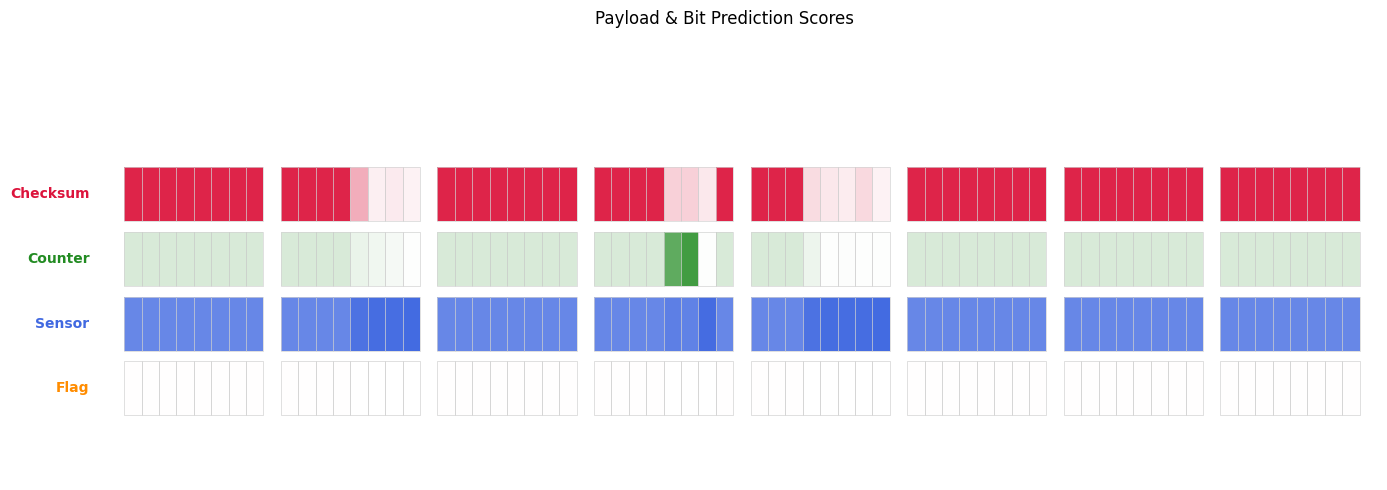

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import re

# Input Text Data containing the scores
text_data = """
Class Checksum: Best Candidate is Bit 0 (Score: 0.9345)
tensor([0.9345, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345,
        0.9345, 0.9345, 0.9345, 0.3493, 0.0680, 0.0856, 0.0535, 0.9345, 0.9345,
        0.9345, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345,
        0.9345, 0.2015, 0.1967, 0.0923, 0.9345, 0.9345, 0.9345, 0.9345, 0.1498,
        0.1002, 0.0768, 0.1619, 0.0535, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345,
        0.9345, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345,
        0.9345, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345,
        0.9345], device='cuda:0')
Class Counter: Best Candidate is Bit 29 (Score: 0.8565)
tensor([0.1751, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751,
        0.1751, 0.1751, 0.1751, 0.0953, 0.0683, 0.0449, 0.0082, 0.1751, 0.1751,
        0.1751, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751,
        0.1751, 0.7260, 0.8565, 0.0088, 0.1751, 0.1751, 0.1751, 0.1751, 0.0799,
        0.0095, 0.0117, 0.0091, 0.0082, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751,
        0.1751, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751,
        0.1751, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751,
        0.1751], device='cuda:0')
Class Sensor: Best Candidate is Bit 15 (Score: 0.9890)
tensor([0.7987, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987,
        0.7987, 0.7987, 0.7987, 0.9372, 0.9784, 0.9681, 0.9890, 0.7987, 0.7987,
        0.7987, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987,
        0.7987, 0.8548, 0.8340, 0.9818, 0.7987, 0.7987, 0.7987, 0.7987, 0.9420,
        0.9760, 0.9713, 0.9764, 0.9890, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987,
        0.7987, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987,
        0.7987, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987,
        0.7987], device='cuda:0')
Class Flag: Best Candidate is Bit 0 (Score: 0.0034)
tensor([0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034,
        0.0034, 0.0034, 0.0034, 0.0011, 0.0010, 0.0010, 0.0013, 0.0034, 0.0034,
        0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034,
        0.0034, 0.0010, 0.0011, 0.0012, 0.0034, 0.0034, 0.0034, 0.0034, 0.0011,
        0.0013, 0.0012, 0.0012, 0.0013, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034,
        0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034,
        0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034,
        0.0034], device='cuda:0')
"""

# --- 1. Parsing Logic ---
pattern_numbers = re.compile(r"\d+\.\d+")
sections = text_data.split("Class")[1:] # Split by "Class" keyword
parsed_data = {}

for section in sections:
    lines = section.split('\n')
    # Get class name (e.g., "Checksum")
    class_name = lines[0].split(":")[0].strip()
    
    # Extract all numbers from the rest of the section
    numbers = []
    for line in lines[1:]:
        nums = pattern_numbers.findall(line)
        numbers.extend([float(n) for n in nums])
    
    if numbers:
        parsed_data[class_name] = numbers

# --- 2. Frame Data Setup ---
frame = "140#000AFD4300000D00"
id_str, data_str = frame.split("#")
payload = [int(data_str[i:i+2], 16) for i in range(0, len(data_str), 2)]

# --- 3. Visualization ---
fig, ax = plt.subplots(figsize=(14, 5))
ax.set_title("Payload & Bit Prediction Scores")

# Define Colors for each class
class_colors = {
    'Checksum': 'crimson',
    'Counter': 'forestgreen',
    'Sensor': 'royalblue',
    'Flag': 'darkorange'
}

byte_spacing = 9 # 8 bits + 1 gap
row_height = 1
y_payload = 0

# # A. Plot Payload (Top Row)
# for byte_index, value in enumerate(payload):
#     bits = f"{value:08b}"
#     for bit_index, bit in enumerate(bits):
#         x = byte_index * byte_spacing + bit_index
        
#         # Payload Box
#         rect = patches.Rectangle((x, y_payload), 1, row_height,
#                              facecolor="white" if bit=="0" else "black",
#                              edgecolor="black")
#         ax.add_patch(rect)
        
#         # Payload Text (Bits)
#         ax.text(x + 0.5, y_payload + 0.5, bit,
#                 ha="center", va="center", 
#                 color="red" if bit=="0" else "white", fontsize=8)

#     # Byte Label
#     ax.text(byte_index * byte_spacing + 4, y_payload + 1.2, f"Byte{byte_index}", ha="center", fontsize=9)

# B. Plot Class Scores (Subsequent Rows)
class_names = ['Checksum', 'Counter', 'Sensor', 'Flag']
y_offset = -1.5 # Start below payload

for class_name in class_names:
    scores = parsed_data[class_name]
    max_score=np.max(scores)
    base_color = class_colors[class_name]
    
    # Label for the row
    ax.text(-2, y_offset + 0.5, class_name, ha="right", va="center", 
            fontsize=10, fontweight='bold', color=base_color)
    
    bit_counter = 0
    for byte_index in range(8):
        for bit_index in range(8):
            x = byte_index * byte_spacing + bit_index
            if bit_counter < len(scores):
                score = scores[bit_counter]
                
                # Plot Score Box
                # Use 'alpha' to represent the score (shading 0-1)
                rect = patches.Rectangle((x, y_offset), 1, row_height,
                                     facecolor=base_color,
                                     alpha=score, 
                                     edgecolor="none")
                ax.add_patch(rect)
                
                # Optional: Light border to keep grid visible
                rect_border = patches.Rectangle((x, y_offset), 1, row_height,
                                     facecolor="none",
                                     edgecolor="lightgray", linewidth=0.5)
                ax.add_patch(rect_border)

                bit_counter += 1
            
    y_offset -= 1.2 # Move down for next class

# Final cleanup
ax.set_xlim(-3, 8 * byte_spacing)
ax.set_ylim(y_offset, 2)
ax.axis("off")

plt.tight_layout()
plt.show()

Checksum 0.7841109374999999
Counter 0.17236875000000002
Sensor 0.8270375000000001
Flag 0.002978125


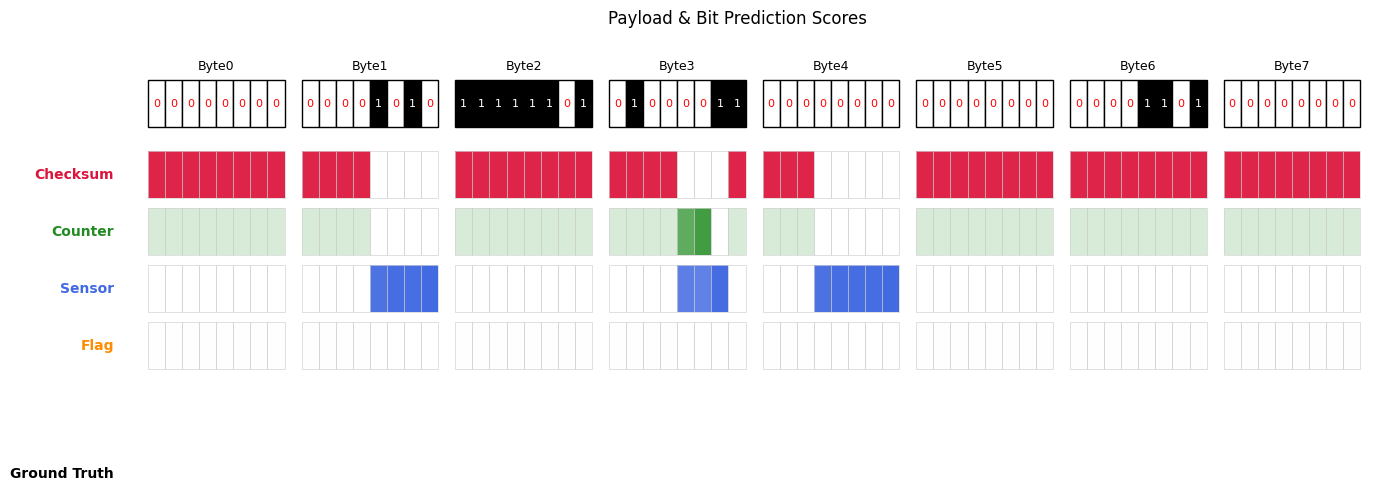

In [35]:
# --- 1. Manual Ground Truth Array ---
# Map: 0:Spare, 1:CHECKSUM, 2:COUNTER, 3:SENSOR, 4:BIT_FLAG
# Constructing based on:
# - Bytes 0-1: Sensor (3)
# - Byte 2: Spare (0)
# - Byte 3: Bits 31-28 Spare(0), Bits 27-25 Counter(2), Bit 24 Spare(0)
# - Byte 4: Checksum (1)
# - Bytes 5-7: Spare (0)

ground_truth_classes = [
    # Byte 0 (Sensor)
    3, 3, 3, 3, 3, 3, 3, 3,
    # Byte 1 (Sensor)
    3, 3, 3, 3, 3, 3, 3, 3,
    # Byte 2 (Spare)
    0, 0, 0, 0, 0, 0, 0, 0,
    # Byte 3 (Spare, Counter, Spare)
    0, 0, 0, 0, 2, 2, 2, 0,
    # Byte 4 (Checksum)
    1, 1, 1, 1, 1, 1, 1, 1,
    # Byte 5 (Spare)
    0, 0, 0, 0, 0, 0, 0, 0,
    # Byte 6 (Spare)
    0, 0, 0, 0, 0, 0, 0, 0,
    # Byte 7 (Spare)
    0, 0, 0, 0, 0, 0, 0, 0
]


text_data = """
--- Bit Inspection for Label: [1 1 1 0] ---
Class Checksum: Best Candidate is Bit 0 (Score: 0.9345)
tensor([0.9345, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345,
        0.9345, 0.9345, 0.9345, 0.3493, 0.0680, 0.0856, 0.0535, 0.9345, 0.9345,
        0.9345, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345,
        0.9345, 0.2015, 0.1967, 0.0923, 0.9345, 0.9345, 0.9345, 0.9345, 0.1498,
        0.1002, 0.0768, 0.1619, 0.0535, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345,
        0.9345, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345,
        0.9345, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345, 0.9345,
        0.9345], device='cuda:0')
Class Counter: Best Candidate is Bit 29 (Score: 0.8565)
tensor([0.1751, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751,
        0.1751, 0.1751, 0.1751, 0.0953, 0.0683, 0.0449, 0.0082, 0.1751, 0.1751,
        0.1751, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751,
        0.1751, 0.7260, 0.8565, 0.0088, 0.1751, 0.1751, 0.1751, 0.1751, 0.0799,
        0.0095, 0.0117, 0.0091, 0.0082, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751,
        0.1751, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751,
        0.1751, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751, 0.1751,
        0.1751], device='cuda:0')
Class Sensor: Best Candidate is Bit 15 (Score: 0.9890)
tensor([0.7987, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987,
        0.7987, 0.7987, 0.7987, 0.9372, 0.9784, 0.9681, 0.9890, 0.7987, 0.7987,
        0.7987, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987,
        0.7987, 0.8548, 0.8340, 0.9818, 0.7987, 0.7987, 0.7987, 0.7987, 0.9420,
        0.9760, 0.9713, 0.9764, 0.9890, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987,
        0.7987, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987,
        0.7987, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987, 0.7987,
        0.7987], device='cuda:0')
Class Flag: Best Candidate is Bit 0 (Score: 0.0034)
tensor([0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034,
        0.0034, 0.0034, 0.0034, 0.0011, 0.0010, 0.0010, 0.0013, 0.0034, 0.0034,
        0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034,
        0.0034, 0.0010, 0.0011, 0.0012, 0.0034, 0.0034, 0.0034, 0.0034, 0.0011,
        0.0013, 0.0012, 0.0012, 0.0013, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034,
        0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034,
        0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034, 0.0034,
        0.0034], device='cuda:0')"""


# --- 1. Parsing Logic ---
pattern_numbers = re.compile(r"\d+\.\d+")
sections = text_data.split("Class")[1:] # Split by "Class" keyword
parsed_data = {}

for section in sections:
    lines = section.split('\n')
    # Get class name (e.g., "Checksum")
    class_name = lines[0].split(":")[0].strip()
    
    # Extract all numbers from the rest of the section
    numbers = []
    for line in lines[1:]:
        nums = pattern_numbers.findall(line)
        numbers.extend([float(n) for n in nums])
    
    if numbers:
        parsed_data[class_name] = numbers

# --- 2. Frame Data Setup ---
frame = "140#000AFD4300000D00"
id_str, data_str = frame.split("#")
payload = [int(data_str[i:i+2], 16) for i in range(0, len(data_str), 2)]

# --- 3. Visualization ---
fig, ax = plt.subplots(figsize=(14, 5))
ax.set_title("Payload & Bit Prediction Scores")

# Define Colors for each class
class_colors = {
    'Checksum': 'crimson',
    'Counter': 'forestgreen',
    'Sensor': 'royalblue',
    'Flag': 'darkorange'
}

byte_spacing = 9 # 8 bits + 1 gap
row_height = 1
y_payload = 0

# A. Plot Payload (Top Row)
for byte_index, value in enumerate(payload):
    bits = f"{value:08b}"
    for bit_index, bit in enumerate(bits):
        x = byte_index * byte_spacing + bit_index
        
        # Payload Box
        rect = patches.Rectangle((x, y_payload), 1, row_height,
                             facecolor="white" if bit=="0" else "black",
                             edgecolor="black")
        ax.add_patch(rect)
        
        # Payload Text (Bits)
        ax.text(x + 0.5, y_payload + 0.5, bit,
                ha="center", va="center", 
                color="red" if bit=="0" else "white", fontsize=8)

    # Byte Label
    ax.text(byte_index * byte_spacing + 4, y_payload + 1.2, f"Byte{byte_index}", ha="center", fontsize=9)

# --- ROW 2: Manual Ground Truth ---
ax.text(-2, y_cursor + 0.5, "Ground Truth", ha="right", va="center", 
        fontsize=10, fontweight='bold', color="black")

for bit_idx, class_id in enumerate(ground_truth_classes):
    byte_index = bit_idx // 8
    bit_inner = bit_idx % 8
    x = byte_index * byte_spacing + bit_inner
    
    color = class_map_colors.get(class_id, 'lightgray')
    
    # Draw block
    rect = patches.Rectangle((x, y_cursor), 1, row_height,
                             facecolor=color, edgecolor="lightgray")
    ax.add_patch(rect)
    
    # Optional: If not Spare, make border darker
    if class_id != 0:
        rect.set_edgecolor("black")
        rect.set_linewidth(1)

# B. Plot Class Scores (Subsequent Rows)
class_names = ['Checksum', 'Counter', 'Sensor', 'Flag']
y_offset = -1.5 # Start below payload

for class_name in class_names:
    scores = parsed_data[class_name]
    mean_score=np.mean(scores)
    print(class_name, mean_score)
    base_color = class_colors[class_name]
    
    # Label for the row
    ax.text(-2, y_offset + 0.5, class_name, ha="right", va="center", 
            fontsize=10, fontweight='bold', color=base_color)
    
    bit_counter = 0
    for byte_index in range(8):
        for bit_index in range(8):
            x = byte_index * byte_spacing + bit_index
            if bit_counter < len(scores):
                score = scores[bit_counter]
                
                # Plot Score Box
                # Use 'alpha' to represent the score (shading 0-1)
                rect = patches.Rectangle((x, y_offset), 1, row_height,
                                     facecolor=base_color,
                                     alpha=score if score>mean_score else 0, 
                                     edgecolor="none")
                ax.add_patch(rect)
                
                # Optional: Light border to keep grid visible
                rect_border = patches.Rectangle((x, y_offset), 1, row_height,
                                     facecolor="none",
                                     edgecolor="lightgray", linewidth=0.5)
                ax.add_patch(rect_border)

                bit_counter += 1
            
    y_offset -= 1.2 # Move down for next class

# Final cleanup
ax.set_xlim(-3, 8 * byte_spacing)
ax.set_ylim(y_offset, 2)
ax.axis("off")

plt.tight_layout()
plt.show()

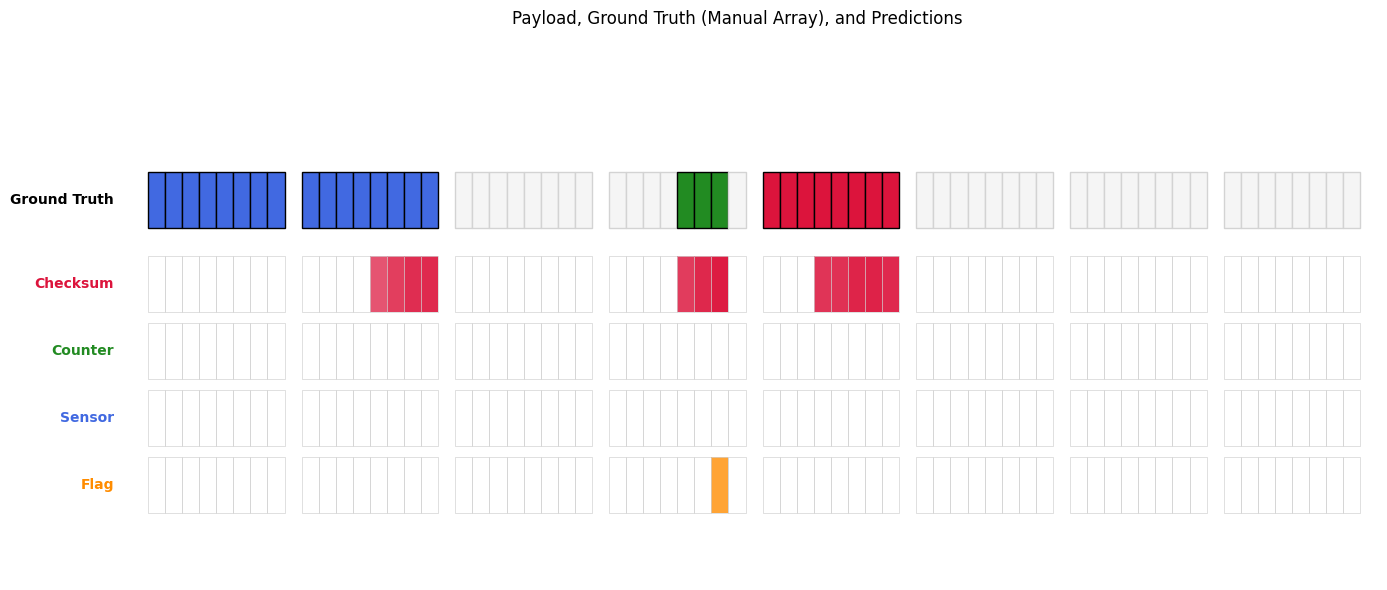

In [34]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import re
import numpy as np

# --- 1. Manual Ground Truth Array ---
# Map: 0:Spare, 1:CHECKSUM, 2:COUNTER, 3:SENSOR, 4:BIT_FLAG
# Constructing based on:
# - Bytes 0-1: Sensor (3)
# - Byte 2: Spare (0)
# - Byte 3: Bits 31-28 Spare(0), Bits 27-25 Counter(2), Bit 24 Spare(0)
# - Byte 4: Checksum (1)
# - Bytes 5-7: Spare (0)

ground_truth_classes = [
    # Byte 0 (Sensor)
    3, 3, 3, 3, 3, 3, 3, 3,
    # Byte 1 (Sensor)
    3, 3, 3, 3, 3, 3, 3, 3,
    # Byte 2 (Spare)
    0, 0, 0, 0, 0, 0, 0, 0,
    # Byte 3 (Spare, Counter, Spare)
    0, 0, 0, 0, 2, 2, 2, 0,
    # Byte 4 (Checksum)
    1, 1, 1, 1, 1, 1, 1, 1,
    # Byte 5 (Spare)
    0, 0, 0, 0, 0, 0, 0, 0,
    # Byte 6 (Spare)
    0, 0, 0, 0, 0, 0, 0, 0,
    # Byte 7 (Spare)
    0, 0, 0, 0, 0, 0, 0, 0
]

# --- 2. Input Prediction Data ---
prediction_text = """
--- Bit Inspection for Label: [1 1 1 0] ---
Class Checksum: Best Candidate is Bit 30 (Score: 0.9683)
tensor([0.4787, 0.4787, 0.4787, 0.4787, 0.4787, 0.4787, 0.4787, 0.4787, 0.4787,
        0.4787, 0.5583, 0.6149, 0.7246, 0.8233, 0.8956, 0.9056, 0.4384, 0.4384,
        0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384,
        0.4384, 0.8321, 0.9184, 0.9683, 0.4384, 0.4384, 0.4384, 0.5513, 0.8644,
        0.8793, 0.9344, 0.9398, 0.9100, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384,
        0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384,
        0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384, 0.4384,
        0.4384], device='cuda:0', grad_fn=<ClampBackward1>)
Class Counter: Best Candidate is Bit 30 (Score: 0.4286)
tensor([0.4100, 0.4100, 0.4100, 0.4100, 0.4100, 0.4100, 0.4100, 0.4100, 0.4100,
        0.4100, 0.3916, 0.3924, 0.3769, 0.3710, 0.3721, 0.3473, 0.4020, 0.4020,
        0.4020, 0.4020, 0.4020, 0.4020, 0.4020, 0.4020, 0.4020, 0.4020, 0.4020,
        0.4020, 0.4282, 0.3581, 0.4286, 0.4020, 0.4020, 0.4020, 0.3851, 0.3893,
        0.3570, 0.3501, 0.3824, 0.3502, 0.4020, 0.4020, 0.4020, 0.4020, 0.4020,
        0.4020, 0.4020, 0.4020, 0.4020, 0.4020, 0.4020, 0.4020, 0.4020, 0.4020,
        0.4020, 0.4020, 0.4020, 0.4020, 0.4020, 0.4020, 0.4020, 0.4020, 0.4020,
        0.4020], device='cuda:0', grad_fn=<ClampBackward1>)
Class Sensor: Best Candidate is Bit 16 (Score: 0.5997)
tensor([0.5818, 0.5818, 0.5818, 0.5818, 0.5818, 0.5818, 0.5818, 0.5818, 0.5818,
        0.5818, 0.4996, 0.4540, 0.3538, 0.2745, 0.2137, 0.1838, 0.5997, 0.5997,
        0.5997, 0.5997, 0.5997, 0.5997, 0.5997, 0.5997, 0.5997, 0.5997, 0.5997,
        0.5997, 0.2401, 0.2000, 0.1000, 0.5997, 0.5997, 0.5997, 0.5031, 0.2400,
        0.2461, 0.1446, 0.1366, 0.1772, 0.5997, 0.5997, 0.5997, 0.5997, 0.5997,
        0.5997, 0.5997, 0.5997, 0.5997, 0.5997, 0.5997, 0.5997, 0.5997, 0.5997,
        0.5997, 0.5997, 0.5997, 0.5997, 0.5997, 0.5997, 0.5997, 0.5997, 0.5997,
        0.5997], device='cuda:0', grad_fn=<ClampBackward1>)
Class Flag: Best Candidate is Bit 30 (Score: 0.7918)
tensor([0.4552, 0.4552, 0.4552, 0.4552, 0.4552, 0.4552, 0.4552, 0.4552, 0.4552,
        0.4552, 0.4444, 0.4412, 0.3991, 0.4110, 0.4555, 0.4122, 0.4662, 0.4662,
        0.4662, 0.4662, 0.4662, 0.4662, 0.4662, 0.4662, 0.4662, 0.4662, 0.4662,
        0.4662, 0.4182, 0.4984, 0.7918, 0.4662, 0.4662, 0.4662, 0.4256, 0.3776,
        0.3911, 0.5389, 0.5614, 0.4059, 0.4662, 0.4662, 0.4662, 0.4662, 0.4662,
        0.4662, 0.4662, 0.4662, 0.4662, 0.4662, 0.4662, 0.4662, 0.4662, 0.4662,
        0.4662, 0.4662, 0.4662, 0.4662, 0.4662, 0.4662, 0.4662, 0.4662, 0.4662,
        0.4662], device='cuda:0', grad_fn=<ClampBackward1>)"""

# Parsing Predictions
pattern_numbers = re.compile(r"\d+\.\d+")
sections = prediction_text.split("Class")[1:]
parsed_preds = {}
for section in sections:
    lines = section.split('\n')
    class_name = lines[0].split(":")[0].strip()
    numbers = []
    for line in lines[1:]:
        nums = pattern_numbers.findall(line)
        numbers.extend([float(n) for n in nums])
    if numbers:
        parsed_preds[class_name] = numbers

# --- 3. Setup Visualization ---
frame = "140#000AFD4300000D00"
id_str, data_str = frame.split("#")
payload = [int(data_str[i:i+2], 16) for i in range(0, len(data_str), 2)]

fig, ax = plt.subplots(figsize=(14, 6))
ax.set_title("Payload, Ground Truth (Manual Array), and Predictions")

# Define Colors and Mapping
class_map_colors = {
    0: 'whitesmoke',   # Spare
    1: 'crimson',      # Checksum
    2: 'forestgreen',  # Counter
    3: 'royalblue',    # Sensor
    4: 'darkorange'    # Flag
}

class_names = ['Checksum', 'Counter', 'Sensor', 'Flag']
name_to_id = {'Checksum': 1, 'Counter': 2, 'Sensor': 3, 'Flag': 4}

byte_spacing = 9 
row_height = 1
y_cursor = 0

# # --- ROW 1: Payload ---
# for byte_index, value in enumerate(payload):
#     bits = f"{value:08b}"
#     for bit_index, bit in enumerate(bits):
#         x = byte_index * byte_spacing + bit_index
#         rect = patches.Rectangle((x, y_cursor), 1, row_height,
#                              facecolor="white" if bit=="0" else "black",
#                              edgecolor="black")
#         ax.add_patch(rect)
#         ax.text(x + 0.5, y_cursor + 0.5, bit, ha="center", va="center", 
#                 color="red" if bit=="0" else "white", fontsize=8)
#     ax.text(byte_index * byte_spacing + 4, y_cursor + 1.2, f"Byte{byte_index}", ha="center", fontsize=9)

y_cursor -= 1.5

# --- ROW 2: Manual Ground Truth ---
ax.text(-2, y_cursor + 0.5, "Ground Truth", ha="right", va="center", 
        fontsize=10, fontweight='bold', color="black")

for bit_idx, class_id in enumerate(ground_truth_classes):
    byte_index = bit_idx // 8
    bit_inner = bit_idx % 8
    x = byte_index * byte_spacing + bit_inner
    
    color = class_map_colors.get(class_id, 'lightgray')
    
    # Draw block
    rect = patches.Rectangle((x, y_cursor), 1, row_height,
                             facecolor=color, edgecolor="lightgray")
    ax.add_patch(rect)
    
    # Optional: If not Spare, make border darker
    if class_id != 0:
        rect.set_edgecolor("black")
        rect.set_linewidth(1)

y_cursor -= 1.5

# --- ROW 3+: Predictions (Normalized) ---
for class_name in class_names:
    scores = parsed_preds[class_name]
    mean_score = np.mean(scores)
    
    # Get color from name mapping
    cid = name_to_id[class_name]
    base_color = class_map_colors[cid]
    
    ax.text(-2, y_cursor + 0.5, class_name, ha="right", va="center", 
            fontsize=10, fontweight='bold', color=base_color)
    
    bit_counter = 0
    for byte_index in range(8):
        for bit_index in range(8):
            x = byte_index * byte_spacing + bit_index
            if bit_counter < len(scores):
                score = scores[bit_counter]
                
                # Normalize
                alpha_val = score / max_score if max_score > 0 else 0
                alpha_val = min(max(alpha_val, 0), 1)
                
                rect = patches.Rectangle((x, y_cursor), 1, row_height,
                                     facecolor=base_color,
                                     alpha=score if score> mean_score+0.1 else 0, 
                                     edgecolor="none")
                ax.add_patch(rect)
                
                # Best Candidate Border
                rect_border = patches.Rectangle((x, y_cursor), 1, row_height,
                                     facecolor="none",
                                     edgecolor="lightgray", linewidth=0.5)
                ax.add_patch(rect_border)
            bit_counter += 1
            
    y_cursor -= 1.2

ax.set_xlim(-3, 8 * byte_spacing)
ax.set_ylim(y_cursor, 2)
ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:


import matplotlib.pyplot as plt
import matplotlib.patches as patches
import re
import numpy as np

# --- 1. Manual Ground Truth Array ---
# Map: 0:Spare, 1:CHECKSUM, 2:COUNTER, 3:SENSOR, 4:BIT_FLAG
# Constructing based on:
# - Bytes 0-1: Sensor (3)
# - Byte 2: Spare (0)
# - Byte 3: Bits 31-28 Spare(0), Bits 27-25 Counter(2), Bit 24 Spare(0)
# - Byte 4: Checksum (1)
# - Bytes 5-7: Spare (0)

ground_truth_classes = [
    # Byte 0 (Sensor)
    3, 3, 3, 3, 3, 3, 3, 3,
    # Byte 1 (Sensor)
    3, 3, 3, 3, 3, 3, 3, 3,
    # Byte 2 (Spare)
    0, 0, 0, 0, 0, 0, 0, 0,
    # Byte 3 (Spare, Counter, Spare)
    0, 0, 0, 0, 2, 2, 2, 0,
    # Byte 4 (Checksum)
    1, 1, 1, 1, 1, 1, 1, 1,
    # Byte 5 (Spare)
    0, 0, 0, 0, 0, 0, 0, 0,
    # Byte 6 (Spare)
    0, 0, 0, 0, 0, 0, 0, 0,
    # Byte 7 (Spare)
    0, 0, 0, 0, 0, 0, 0, 0
]

# --- 2. Input Prediction Data ---
prediction_text = """
Class Checksum: Best Candidate is Bit 0 (Score: 0.9650)
tensor([0.9650, 0.9650, 0.9650, 0.9650, 0.9650, 0.9650, 0.9650, 0.9650, 0.1416,
        0.1416, 0.0831, 0.2769, 0.2383, 0.1298, 0.3266, 0.0801, 0.9650, 0.9650,
        0.9650, 0.9650, 0.9650, 0.9650, 0.9650, 0.9650, 0.9650, 0.9650, 0.9650,
        0.9650, 0.5127, 0.3899, 0.0483, 0.9650, 0.1025, 0.1025, 0.1081, 0.0721,
        0.1608, 0.1325, 0.0809, 0.0801, 0.9650, 0.9650, 0.9650, 0.9650, 0.9650,
        0.9650, 0.9650, 0.9650, 0.9650, 0.9650, 0.9650, 0.9650, 0.9650, 0.9650,
        0.9650, 0.9650, 0.9650, 0.9650, 0.9650, 0.9650, 0.9650, 0.9650, 0.9650,
        0.9650], device='cuda:0')
Class Counter: Best Candidate is Bit 29 (Score: 0.5290)
tensor([0.0168, 0.0168, 0.0168, 0.0168, 0.0168, 0.0168, 0.0168, 0.0168, 0.0050,
        0.0050, 0.0040, 0.0066, 0.0066, 0.0061, 0.0120, 0.0055, 0.0168, 0.0168,
        0.0168, 0.0168, 0.0168, 0.0168, 0.0168, 0.0168, 0.0168, 0.0168, 0.0168,
        0.0168, 0.2150, 0.5290, 0.0046, 0.0168, 0.0046, 0.0046, 0.0052, 0.0065,
        0.0050, 0.0057, 0.0042, 0.0055, 0.0168, 0.0168, 0.0168, 0.0168, 0.0168,
        0.0168, 0.0168, 0.0168, 0.0168, 0.0168, 0.0168, 0.0168, 0.0168, 0.0168,
        0.0168, 0.0168, 0.0168, 0.0168, 0.0168, 0.0168, 0.0168, 0.0168, 0.0168,
        0.0168], device='cuda:0')
Class Sensor: Best Candidate is Bit 8 (Score: 0.9934)
tensor([0.9061, 0.9061, 0.9061, 0.9061, 0.9061, 0.9061, 0.9061, 0.9061, 0.9934,
        0.9934, 0.9903, 0.9794, 0.9690, 0.9796, 0.9773, 0.9803, 0.9061, 0.9061,
        0.9061, 0.9061, 0.9061, 0.9061, 0.9061, 0.9061, 0.9061, 0.9061, 0.9061,
        0.9061, 0.9070, 0.8907, 0.9875, 0.9061, 0.9884, 0.9884, 0.9924, 0.9880,
        0.9753, 0.9832, 0.9784, 0.9803, 0.9061, 0.9061, 0.9061, 0.9061, 0.9061,
        0.9061, 0.9061, 0.9061, 0.9061, 0.9061, 0.9061, 0.9061, 0.9061, 0.9061,
        0.9061, 0.9061, 0.9061, 0.9061, 0.9061, 0.9061, 0.9061, 0.9061, 0.9061,
        0.9061], device='cuda:0')
Class Flag: Best Candidate is Bit 0 (Score: 0.0098)
tensor([0.0098, 0.0098, 0.0098, 0.0098, 0.0098, 0.0098, 0.0098, 0.0098, 0.0021,
        0.0021, 0.0016, 0.0017, 0.0016, 0.0014, 0.0014, 0.0015, 0.0098, 0.0098,
        0.0098, 0.0098, 0.0098, 0.0098, 0.0098, 0.0098, 0.0098, 0.0098, 0.0098,
        0.0098, 0.0012, 0.0010, 0.0015, 0.0098, 0.0016, 0.0016, 0.0018, 0.0015,
        0.0018, 0.0016, 0.0015, 0.0015, 0.0098, 0.0098, 0.0098, 0.0098, 0.0098,
        0.0098, 0.0098, 0.0098, 0.0098, 0.0098, 0.0098, 0.0098, 0.0098, 0.0098,
        0.0098, 0.0098, 0.0098, 0.0098, 0.0098, 0.0098, 0.0098, 0.0098, 0.0098,
        0.0098], device='cuda:0')
"""

# Parsing Predictions
pattern_numbers = re.compile(r"\d+\.\d+")
sections = prediction_text.split("Class")[1:]
parsed_preds = {}
for section in sections:
    lines = section.split('\n')
    class_name = lines[0].split(":")[0].strip()
    numbers = []
    for line in lines[1:]:
        nums = pattern_numbers.findall(line)
        numbers.extend([float(n) for n in nums])
    if numbers:
        parsed_preds[class_name] = numbers

# --- 3. Setup Visualization ---
frame = "140#000AFD4300000D00"
id_str, data_str = frame.split("#")
payload = [int(data_str[i:i+2], 16) for i in range(0, len(data_str), 2)]

fig, ax = plt.subplots(figsize=(14, 6))
ax.set_title("Payload, Ground Truth (Manual Array), and Predictions")

# Define Colors and Mapping
class_map_colors = {
    0: 'whitesmoke',   # Spare
    1: 'crimson',      # Checksum
    2: 'forestgreen',  # Counter
    3: 'royalblue',    # Sensor
    4: 'darkorange'    # Flag
}

class_names = ['Checksum', 'Counter', 'Sensor', 'Flag']
name_to_id = {'Checksum': 1, 'Counter': 2, 'Sensor': 3, 'Flag': 4}

byte_spacing = 9 
row_height = 1
y_cursor = 0

# # --- ROW 1: Payload ---
# for byte_index, value in enumerate(payload):
#     bits = f"{value:08b}"
#     for bit_index, bit in enumerate(bits):
#         x = byte_index * byte_spacing + bit_index
#         rect = patches.Rectangle((x, y_cursor), 1, row_height,
#                              facecolor="white" if bit=="0" else "black",
#                              edgecolor="black")
#         ax.add_patch(rect)
#         ax.text(x + 0.5, y_cursor + 0.5, bit, ha="center", va="center", 
#                 color="red" if bit=="0" else "white", fontsize=8)
#     ax.text(byte_index * byte_spacing + 4, y_cursor + 1.2, f"Byte{byte_index}", ha="center", fontsize=9)

y_cursor -= 1.5

# --- ROW 2: Manual Ground Truth ---
ax.text(-2, y_cursor + 0.5, "Ground Truth", ha="right", va="center", 
        fontsize=10, fontweight='bold', color="black")

for bit_idx, class_id in enumerate(ground_truth_classes):
    byte_index = bit_idx // 8
    bit_inner = bit_idx % 8
    x = byte_index * byte_spacing + bit_inner
    
    color = class_map_colors.get(class_id, 'lightgray')
    
    # Draw block
    rect = patches.Rectangle((x, y_cursor), 1, row_height,
                             facecolor=color, edgecolor="lightgray")
    ax.add_patch(rect)
    
    # Optional: If not Spare, make border darker
    if class_id != 0:
        rect.set_edgecolor("black")
        rect.set_linewidth(1)

y_cursor -= 1.5

# --- ROW 3+: Predictions (Normalized) ---
for class_name in class_names:
    scores = parsed_preds[class_name]
    mean_score = np.mean(scores)
    
    # Get color from name mapping
    cid = name_to_id[class_name]
    base_color = class_map_colors[cid]
    
    ax.text(-2, y_cursor + 0.5, class_name, ha="right", va="center", 
            fontsize=10, fontweight='bold', color=base_color)
    
    bit_counter = 0
    for byte_index in range(8):
        for bit_index in range(8):
            x = byte_index * byte_spacing + bit_index
            if bit_counter < len(scores):
                score = scores[bit_counter]
                
                # Normalize
                alpha_val = score / max_score if max_score > 0 else 0
                alpha_val = min(max(alpha_val, 0), 1)
                
                rect = patches.Rectangle((x, y_cursor), 1, row_height,
                                     facecolor=base_color,
                                     alpha=score if score> mean_score else 0, 
                                     edgecolor="none")
                ax.add_patch(rect)
                
                # Best Candidate Border
                rect_border = patches.Rectangle((x, y_cursor), 1, row_height,
                                     facecolor="none",
                                     edgecolor="lightgray", linewidth=0.5)
                ax.add_patch(rect_border)
            bit_counter += 1
            
    y_cursor -= 1.2

ax.set_xlim(-3, 8 * byte_spacing)
ax.set_ylim(y_cursor, 2)
ax.axis("off")

plt.tight_layout()
plt.show()